# Worksheet 3 - Low rank representations of galaxy images

In [14]:
import numpy as np
import matplotlib.pyplot as plt
import h5py
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

In [5]:
CLASS_NAMES = [
    'Disturbed', 'Merging', 'Round Smooth', 'In-between Smooth',
    'Cigar Smooth', 'Barred Spiral', 'Unbarred Tight Spiral',
    'Unbarred Loose Spiral', 'Edge-on no Bulge', 'Edge-on with Bulge']

with h5py.File('Galaxy10_DECals_64x64.h5') as F:
    images = np.array(F['images']) # shape (17736, 64, 64, 3)
    labels = np.array(F['ans']) # integer class labels 0..9

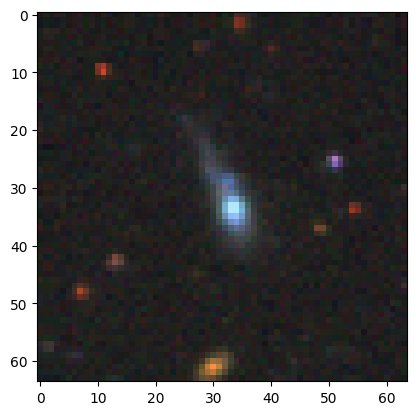

In [6]:
# Display galaxy 27 as a composite RGB image:

plt.imshow(images[27] / 255.)

## Task 1 - Exploration and preprocessing

**Plot example galaxies of each of the morphological classes:**

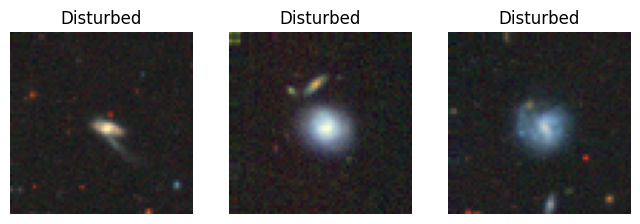

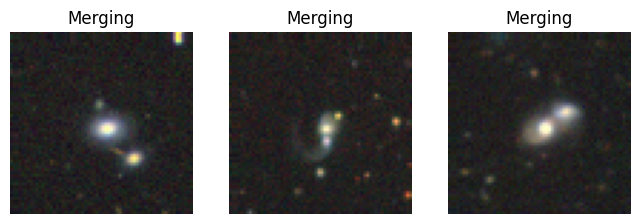

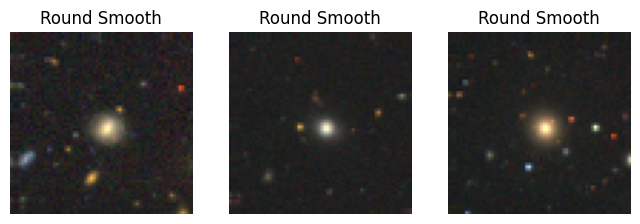

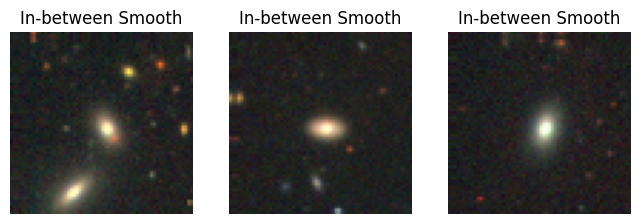

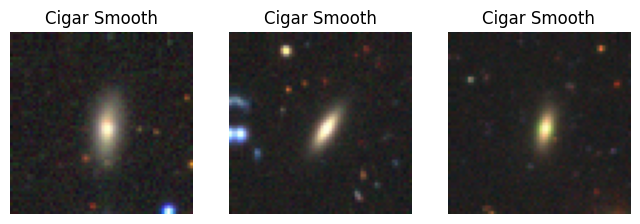

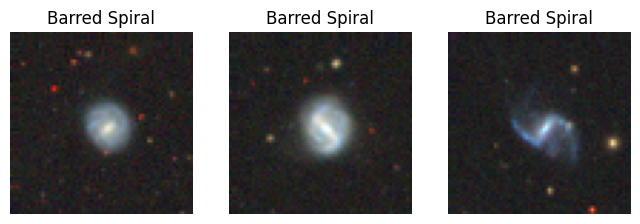

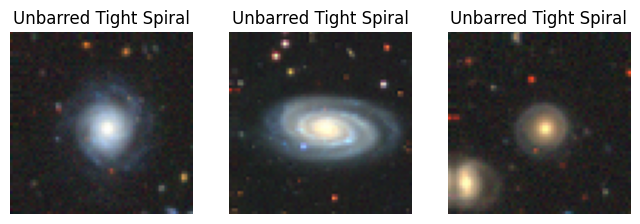

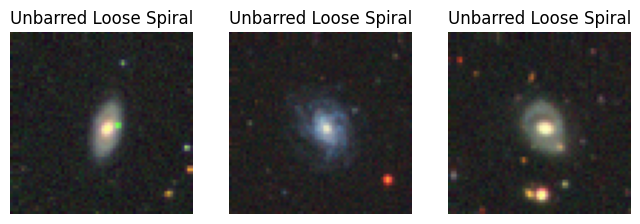

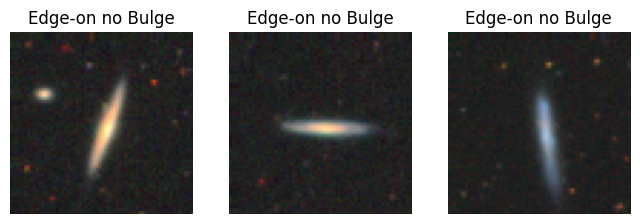

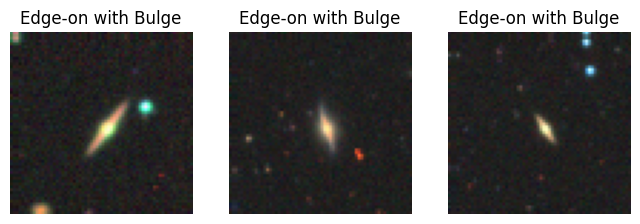

In [10]:
number_examples = 3

np.random.seed(42)  # reproducibility

for class_id in range(10):
    id = np.where(labels == class_id)[0] # get all indices for this class
    
    # randomly pick samples from them
    random_id = np.random.choice(id, number_examples, replace=False)

    plt.figure(figsize=(8, 3))
    
    for i, idx in enumerate(random_id):
        plt.subplot(1, number_examples, i + 1)
        plt.imshow(images[idx] / 255.)
        plt.title(CLASS_NAMES[class_id])
        plt.axis('off')

    plt.show()

**Grayscale:**

In [23]:
gray_images = np.mean(images, axis=3)
gray_images /= 255.0

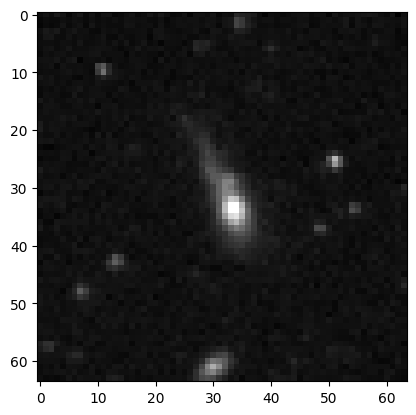

In [24]:
# Display galaxy 27 as a grayscale image:

plt.imshow(gray_images[27] / 255., cmap='gray')

## Task 4 - Convolutional autoencoder: training and reconstruction

**Create subset of 100 barred spirals for testing the CAE_starter_pytorch provided:**

In [13]:
class_id_barred_spirals = 5

idbs = np.where(labels == class_id_barred_spirals)[0]

np.random.seed(42)
selected_id = np.random.choice(idbs, 100, replace=False)

subset_barred_spirals = images[selected_id]

gray_subset_barred_spirals = np.mean(subset_barred_spirals, axis=3) / 255.

np.save("galaxy10_barred_spiral_64x64_100.npy", gray_subset_barred_spirals)

**GPU or CPU:**

In [15]:
# reproducibility
torch.manual_seed(0)
np.random.seed(0)

# use GPU if available, otherwise CPU
device = torch.device('cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu')
print('Using device:', device)

Using device: cpu


**Show properties of the whole sample (all 17 736 images and all galaxy classes):**

In [25]:
print('Loaded:', gray_images.shape, '  dtype:', gray_images.dtype)
print('Pixel range: [{:.3f}, {:.3f}]'.format(gray_images.min(), gray_images.max()))

Loaded: (17736, 64, 64)   dtype: float64
Pixel range: [0.029, 1.000]


**Visualise a few galaxies:**

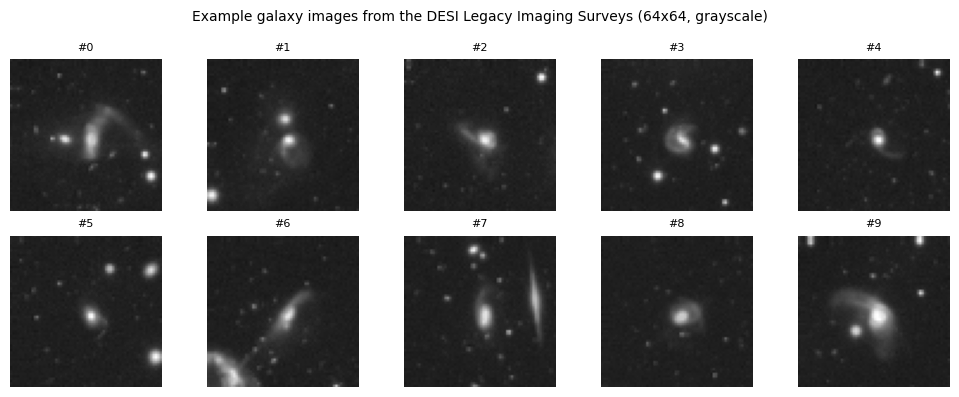

In [26]:
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for i, ax in enumerate(axes.flat):
    ax.imshow(gray_images[i], cmap='gray', vmin=0, vmax=1)
    ax.axis('off')
    ax.set_title(f'#{i}', fontsize=8)
plt.suptitle('Example galaxy images from the DESI Legacy Imaging Surveys (64x64, grayscale)', fontsize=10)
plt.tight_layout()
plt.show()

**Training and Validation/ Dataloader:** 

We use 80% of the sample for training and 20% for validation. Training: 14 189 images, Validation: 3547 images.

PyTorch convolutions expect **channel-first** tensors: shape `(N, C, H, W)`.  
We add a singleton channel dimension with `[:, None, :, :]`.

In [31]:
N_TRAIN    = 14189
BATCH_SIZE = 16

# add channel dim: (N, 1, 64, 64)
x_train = torch.tensor(gray_images[:N_TRAIN,  None, :, :], dtype=torch.float32)
x_val   = torch.tensor(gray_images[N_TRAIN:,  None, :, :], dtype=torch.float32)

train_loader = DataLoader(
    TensorDataset(x_train, x_train),   # input == target (autoencoder)
    batch_size=BATCH_SIZE, shuffle=True
)

print(f'Training images:   {x_train.shape}')
print(f'Validation images: {x_val.shape}')

Training images:   torch.Size([14189, 1, 64, 64])
Validation images: torch.Size([3547, 1, 64, 64])


**Define the convolutional autoencoder**

The architecture mirrors the one from the lecture notes:

| Stage | Layer | Output shape |
|---|---|---|
| Encoder | Conv2d(1→32, 3×3, stride 2) + ReLU | 32×32×32 |
| | Conv2d(32→64, 3×3, stride 2) + ReLU | 16×16×64 |
| | Conv2d(64→128, 3×3, stride 2) + ReLU | 8×8×128 |
| | Flatten + Linear → **latent** | 4 |
| Decoder | Linear → Reshape | 8×8×128 |
| | ConvTranspose2d(128→128, stride 2) + ReLU | 16×16×128 |
| | ConvTranspose2d(128→64, stride 2) + ReLU | 32×32×64 |
| | ConvTranspose2d(64→32, stride 2) + ReLU | 64×64×32 |
| | Conv2d(32→1, 3×3) + Sigmoid | 64×64×1 |

In [32]:
class ConvAutoencoder(nn.Module):
    """Convolutional autoencoder for square single-channel images."""

    def __init__(self, channels: int, size: int, latent_dim: int = 4):
        """
        Parameters
        ----------
        channels  : number of input channels (1 for grayscale)
        size      : spatial size of the input image (must be divisible by 8)
        latent_dim: dimension of the bottleneck (latent space)
        """
        super().__init__()
        assert size % 8 == 0, 'image size must be divisible by 8'
        self.latent_dim = latent_dim
        s = size // 8          # spatial size after 3 stride-2 convolutions
        self.s = s
        flat = 128 * s * s     # number of features before the bottleneck Dense

        # --- Encoder ---
        self.enc_conv = nn.Sequential(
            nn.Conv2d(channels, 32,  3, stride=2, padding=1), nn.ReLU(),
            nn.Conv2d(32,       64,  3, stride=2, padding=1), nn.ReLU(),
            nn.Conv2d(64,       128, 3, stride=2, padding=1), nn.ReLU(),
        )
        self.enc_fc = nn.Linear(flat, latent_dim)

        # --- Decoder ---
        self.dec_fc = nn.Linear(latent_dim, flat)
        self.dec_conv = nn.Sequential(
            nn.ConvTranspose2d(128, 128, 3, stride=2, padding=1, output_padding=1), nn.ReLU(),
            nn.ConvTranspose2d(128,  64, 3, stride=2, padding=1, output_padding=1), nn.ReLU(),
            nn.ConvTranspose2d( 64,  32, 3, stride=2, padding=1, output_padding=1), nn.ReLU(),
            nn.Conv2d(32, channels, 3, stride=1, padding=1),
            nn.Sigmoid(),   # output in [0, 1] to match normalised pixel values
        )

    def encode(self, x: torch.Tensor) -> torch.Tensor:
        """Map an image batch to latent vectors."""
        h = self.enc_conv(x)                      # (N, 128, s, s)
        h = h.view(h.size(0), -1)                 # (N, 128*s*s)  flatten
        return self.enc_fc(h)                      # (N, latent_dim)

    def decode(self, z: torch.Tensor) -> torch.Tensor:
        """Map latent vectors back to images."""
        h = self.dec_fc(z)                         # (N, 128*s*s)
        h = h.view(h.size(0), 128, self.s, self.s) # (N, 128, s, s)  reshape
        return self.dec_conv(h)                    # (N, channels, H, W)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.decode(self.encode(x))

In [33]:
LATENT_DIM = 4
SIZE       = 64
CHANNELS   = 1

model = ConvAutoencoder(channels=CHANNELS, size=SIZE, latent_dim=LATENT_DIM).to(device)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Total trainable parameters: {total_params:,}')
print(model)

Total trainable parameters: 406,533
ConvAutoencoder(
  (enc_conv): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (3): ReLU()
    (4): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (5): ReLU()
  )
  (enc_fc): Linear(in_features=8192, out_features=4, bias=True)
  (dec_fc): Linear(in_features=4, out_features=8192, bias=True)
  (dec_conv): Sequential(
    (0): ConvTranspose2d(128, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), output_padding=(1, 1))
    (1): ReLU()
    (2): ConvTranspose2d(128, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), output_padding=(1, 1))
    (3): ReLU()
    (4): ConvTranspose2d(64, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), output_padding=(1, 1))
    (5): ReLU()
    (6): Conv2d(32, 1, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): Sigmoid()
  )
)


**Training:**

We minimise the mean squared error (MSE) between input and reconstruction:
$$
\mathcal{L} = \frac{1}{N}\sum_{i=1}^N \|\hat{\mathbf{x}}_i - \mathbf{x}_i\|^2.
$$

**Data augmentation:** For the training with only the small 100 image subsample, the images were randomly flipped horizontally and vertically during training to avoid overfitting and to multiply the variety of examples. For the whole sample the training set is with 14 189 images already much larger, the flipping will still be done in order to improve the results.

In [34]:
EPOCHS = 200

optimizer = optim.Adam(model.parameters(), lr=1e-3)
loss_fn   = nn.MSELoss()

x_val_dev = x_val.to(device)

train_losses = []
val_losses   = []

for epoch in range(1, EPOCHS + 1):
    # --- training ---
    model.train()
    epoch_loss = 0.0
    for x_batch, _ in train_loader:
        x_batch = x_batch.to(device)

        # data augmentation: random horizontal / vertical flip of image to increase training data set
        if torch.rand(1).item() > 0.5:
            x_batch = x_batch.flip(dims=[3])   # horizontal flip
        if torch.rand(1).item() > 0.5:
            x_batch = x_batch.flip(dims=[2])   # vertical flip

        optimizer.zero_grad()
        loss = loss_fn(model(x_batch), x_batch)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item() * x_batch.size(0)

    epoch_loss /= N_TRAIN
    train_losses.append(epoch_loss)

    # --- validation ---
    model.eval()
    with torch.no_grad():
        val_loss = loss_fn(model(x_val_dev), x_val_dev).item()
    val_losses.append(val_loss)

    if epoch % 20 == 0:
        print(f'Epoch {epoch:3d}/{EPOCHS}  train loss: {epoch_loss:.5f}  val loss: {val_loss:.5f}')

print('Training complete.')

Epoch  20/200  train loss: 0.00262  val loss: 0.00358
Epoch  40/200  train loss: 0.00254  val loss: 0.00335
Epoch  60/200  train loss: 0.00250  val loss: 0.00329
Epoch  80/200  train loss: 0.00249  val loss: 0.00327
Epoch 100/200  train loss: 0.00247  val loss: 0.00330
Epoch 120/200  train loss: 0.00245  val loss: 0.00330
Epoch 140/200  train loss: 0.00245  val loss: 0.00335
Epoch 160/200  train loss: 0.00244  val loss: 0.00328
Epoch 180/200  train loss: 0.00243  val loss: 0.00325
Epoch 200/200  train loss: 0.00242  val loss: 0.00333
Training complete.


**Training curve**

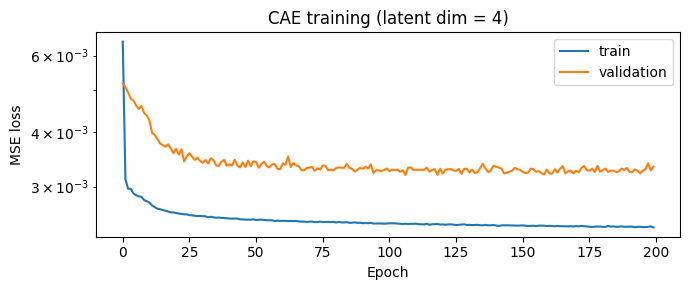

In [35]:
fig, ax = plt.subplots(figsize=(7, 3))
ax.plot(train_losses, label='train')
ax.plot(val_losses,   label='validation')
ax.set_xlabel('Epoch')
ax.set_ylabel('MSE loss')
ax.set_title(f'CAE training (latent dim = {LATENT_DIM})')
ax.legend()
ax.set_yscale('log')
plt.tight_layout()
plt.show()

**Reconstruction quality**

Each column shows one validation galaxy, one galaxy for every morphological class is shown.  
**Top row:** original image.  **Bottom row:** reconstruction from the 4-dimensional latent code.

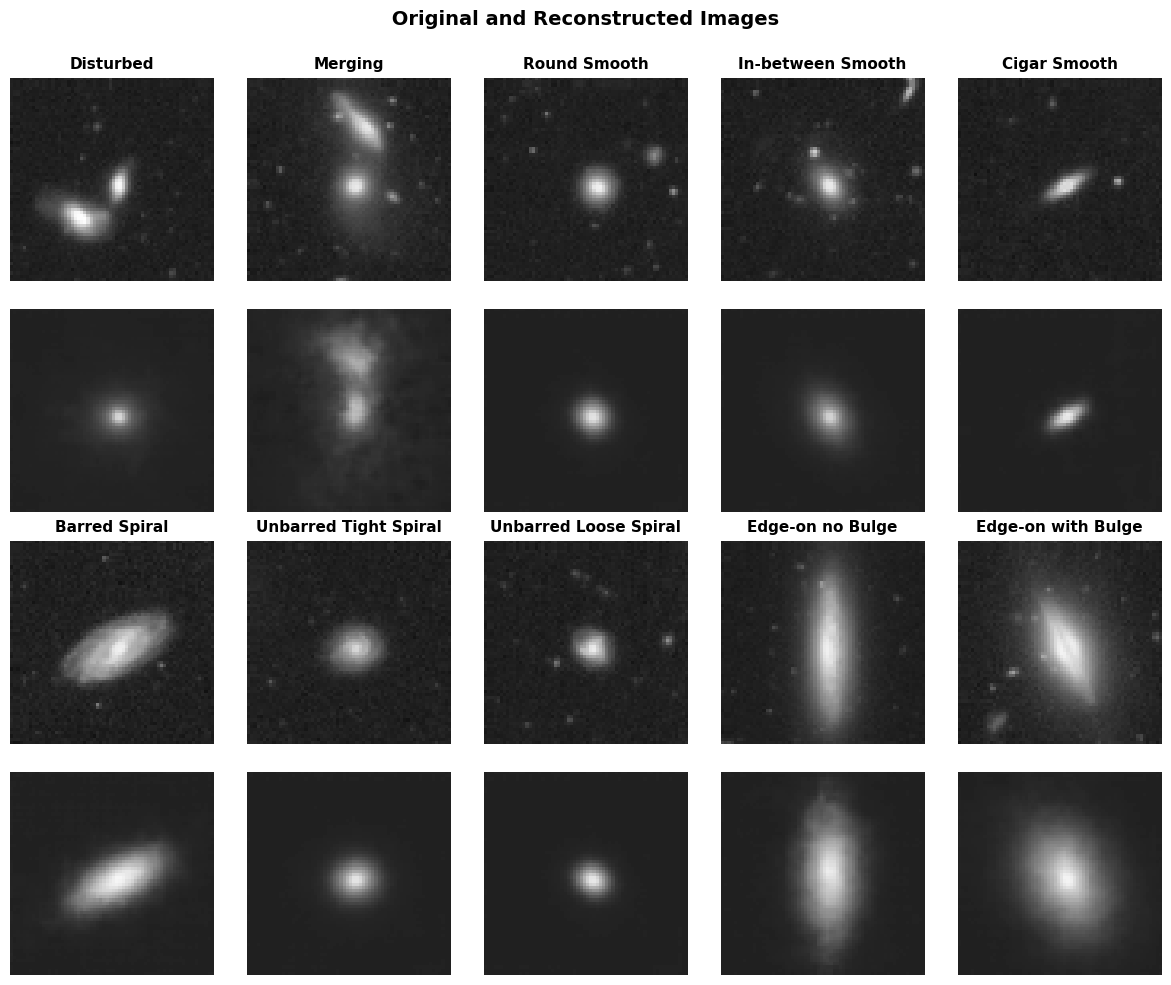

In [57]:
N_CLASSES = 10

np.random.seed(42)  # reproducibility
model.eval()

# pick one random sample for every morphological class
example_id = []
for class_id in range(N_CLASSES):
    found_id = np.where(labels == class_id)[0]
    choice = np.random.choice(found_id)
    example_id.append(choice)

example_id = np.array(example_id)


x_selected = torch.tensor(gray_images[example_id], dtype=torch.float32).unsqueeze(1).to(device)

with torch.no_grad():
    recons = model(x_selected).cpu().numpy()

originals = x_selected.cpu().numpy()

fig, axes = plt.subplots(4, 5, figsize=(12, 10))

for i in range(10):
    row = (i // 5) * 2      # 0 or 2
    col = i % 5

    # original
    axes[row, col].imshow(originals[i, 0], cmap='gray', vmin=0, vmax=1)
    axes[row, col].axis('off')
    axes[row, col].set_title(CLASS_NAMES[i], fontsize=11, fontweight='bold')

    # reconstruction
    axes[row + 1, col].imshow(recons[i, 0], cmap='gray', vmin=0, vmax=1)
    axes[row + 1, col].axis('off')

plt.suptitle(' Original and Reconstructed Images \n', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

**Inspect the latent codes**

Let's look at what the encoder produces for the validation set — the raw 4-dimensional latent vectors.

In [ ]:
model.eval() #evaluation mode not training mode
with torch.no_grad(): #basically lets model run faster
    z_val = model.encode(x_val_dev).cpu().numpy()

print('Latent vectors shape:', z_val.shape)
print('\nPer-dimension statistics:')
print(f'  {"dim":>3}  {"mean":>8}  {"std":>8}  {"min":>8}  {"max":>8}')
for i in range(LATENT_DIM):
    print(f'  {i:>3}  {z_val[:,i].mean():>8.3f}  {z_val[:,i].std():>8.3f}'
          f'  {z_val[:,i].min():>8.3f}  {z_val[:,i].max():>8.3f}')

Latent vectors shape: (3547, 4)

Per-dimension statistics:
  dim      mean       std       min       max
    0     2.004     1.506   -23.139     8.769
    1     0.619     1.533    -7.801    11.402
    2    -0.386     1.209    -6.544     9.647
    3    -0.296     1.672   -15.317     6.556


## Task 5 - Latent space structure

**Encode all galaxy images to obtain their 4-dimensional latent vectors:**

In [ ]:
model.eval() 
X_full = torch.tensor(gray_images, dtype=torch.float32).unsqueeze(1).to(device)

with torch.no_grad():
    z = model.encode(X_full).cpu().numpy()   # encodes to latent vectors (17736, 4)

print('Latent vectors shape:', z.shape)
print('\nPer-dimension statistics:')
print(f'  {"dim":>3}  {"mean":>8}  {"std":>8}  {"min":>8}  {"max":>8}')
for i in range(LATENT_DIM):
    print(f'  {i:>3}  {z[:,i].mean():>8.3f}  {z[:,i].std():>8.3f}'
          f'  {z[:,i].min():>8.3f}  {z[:,i].max():>8.3f}')

Latent vectors shape: (17736, 4)

Per-dimension statistics:
  dim      mean       std       min       max
    0     1.789     1.441   -24.568    11.833
    1     0.569     1.192   -15.501    18.913
    2    -0.089     1.313    -8.064    36.294
    3    -0.415     1.301   -19.183    10.135


**Latent space scatter plot:**

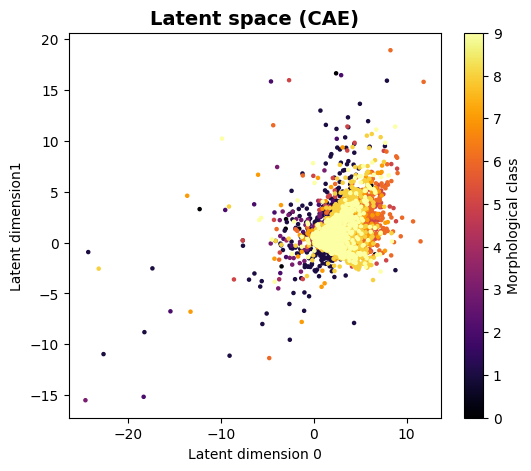

In [92]:
plt.figure(figsize=(6,5))

plt.scatter(z[:,0], z[:,1], c=labels, cmap='inferno', s=5)

plt.xlabel('Latent dimension 0')
plt.ylabel('Latent dimension1')
plt.title('Latent space (CAE)', fontsize=14, fontweight='bold')
plt.colorbar(label='Morphological class')

plt.show()

**Latent dimensional traversal (vary one dimension at a time):**

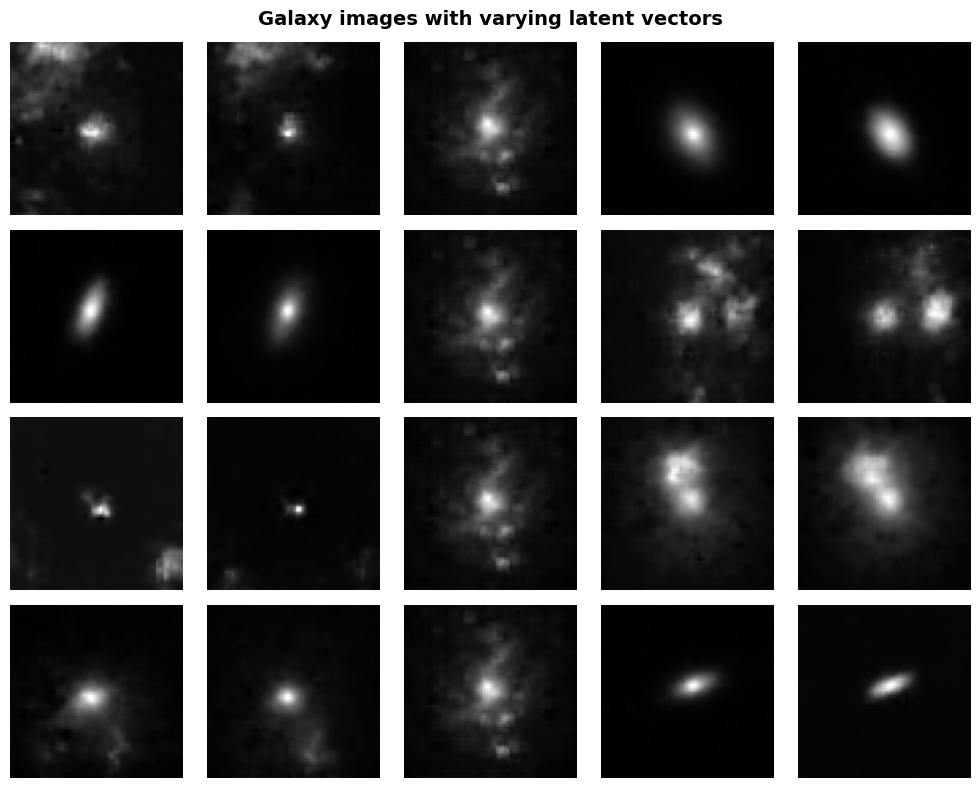

In [114]:
z_std = z.std(axis=0)
values = np.array([-2, -1, 0, 1, 2])

fig, axes = plt.subplots(4, 5, figsize=(10, 8))

with torch.no_grad():
    for dim in range(4):
        for j, v in enumerate(values):

            z_vector = np.zeros(4)
            z_vector[dim] = v * z_std[dim]

            z_tensor = torch.tensor(z_vector, dtype=torch.float32).unsqueeze(0).to(device)

            reconstruction = model.decode(z_tensor).cpu().numpy()[0, 0]

            axes[dim, j].imshow(reconstruction, cmap='gray')
            axes[dim, j].axis('off')

plt.suptitle('Galaxy images with varying latent vectors', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Task 6 - Latent space interpolation and comparison with SVD

**pick two galaxies of visually distinct morphological types:**

In [127]:
galaxy1 = np.where(labels==2)[0][0]   # round smooth
galaxy2 = np.where(labels==8)[0][0]   # edge-on spiral

**CAE interpolation:**

In [128]:
model.eval() 
galaxy1_tensor = torch.tensor(gray_images[galaxy1], dtype=torch.float32).unsqueeze(0).unsqueeze(0).to(device)
galaxy2_tensor = torch.tensor(gray_images[galaxy2], dtype=torch.float32).unsqueeze(0).unsqueeze(0).to(device)

with torch.no_grad():
    z1 = model.encode(galaxy1_tensor).cpu()
    z2 = model.encode(galaxy2_tensor).cpu()

print(z1.shape)
print(z2.shape)


torch.Size([1, 4])
torch.Size([1, 4])


**Decode linear interpolation:**

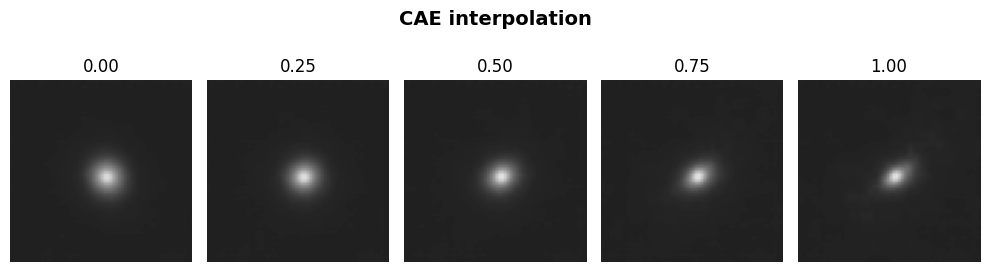

In [129]:
alpha = [0, 0.25, 0.5, 0.75, 1]

fig, axes = plt.subplots(1, 5, figsize=(10, 3))

model.eval()

with torch.no_grad():

    # ensure latent vectors are proper shape (1, latent_dim)
    z1 = z1.to(device)
    z2 = z2.to(device)

    for i, a in enumerate(alpha):

        z_interp = (1 - a) * z1 + a * z2
        z_interp = z_interp.to(device)

        recon = model.decode(z_interp)

        recon_img = recon.cpu().numpy()[0, 0]

        axes[i].imshow(recon_img, cmap='gray', vmin=0, vmax=1)
        axes[i].axis('off')
        axes[i].set_title(f'{a:.2f}')

plt.suptitle('CAE interpolation', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

**Same for SVD interpolation:**

In [ ]:
X = gray_images.reshape(gray_images.shape[0], -1)  # (N, 4096)
X = X - X.mean(axis=0)  # center data